## Импорт необходимых библиотек

In [68]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from keras.layers import Embedding,  LSTM, Dense, Dropout
from keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences


## Рассмотрим входной датасет и примеры из него

In [69]:
# Загрузим датасет с Kaggle
dataset_path = kagglehub.dataset_download('adisongoh/it-service-ticket-classification-dataset')
print("Путь к данным:", dataset_path)

# Читаем CSV внутри неё
data_files = os.listdir(dataset_path)
print("Файлы в директории датасета:", data_files)

csv_file = [f for f in data_files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(dataset_path, csv_file))

# Просмотр первых строк датасета
print(df.head())


Путь к данным: /Users/smoukz_/.cache/kagglehub/datasets/adisongoh/it-service-ticket-classification-dataset/versions/1
Файлы в директории датасета: ['.DS_Store', 'all_tickets_processed_improved_v3.csv']
                                            Document    Topic_group
0  connection with icon icon dear please setup ic...       Hardware
1  work experience user work experience user hi w...         Access
2  requesting for meeting requesting meeting hi p...       Hardware
3  reset passwords for external accounts re expir...         Access
4  mail verification warning hi has got attached ...  Miscellaneous


## Рассмотрим статистику по классам и их распределение

Количество объектов в каждом классе:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


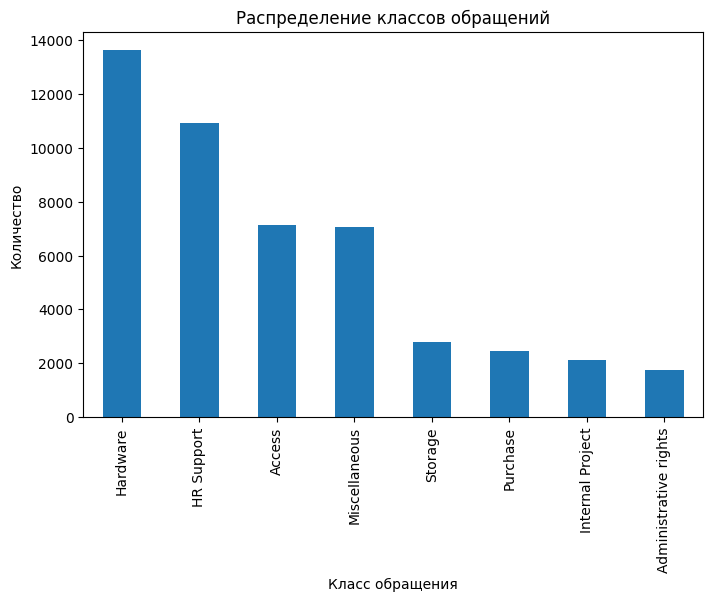

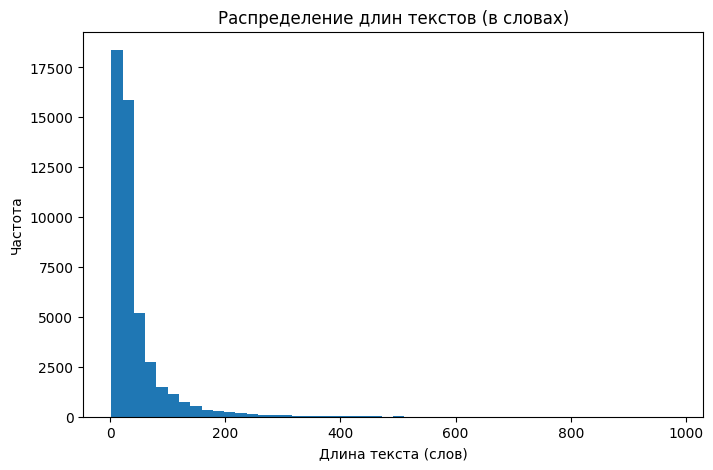


Примеры тикетов по классам:
Класс 'Hardware': connection with icon icon dear please setup icon per icon engineers please let other details needed ...
Класс 'Access': work experience user work experience user hi work experience student coming next his name much appre...
Класс 'Miscellaneous': mail verification warning hi has got attached please addresses best regards monitoring analyst verif...
Класс 'HR Support': access request dear modules report report cost thank much regards...
Класс 'Purchase': system hello movement has left available device please kind device denmark copenhagen denmark please...
Класс 'Administrative rights': notification wireless devices upgrade cr medium wireless devices upgrade cr medium hi please announc...
Класс 'Storage': mailbox almost full mailbox almost hi mailbox almost kind thanks regards senior infrastructure engin...
Класс 'Internal Project': opportunity into pas known pipeline opportunity known pipeline hi please import bellow opportunity k...


In [ ]:
# Основные статистики по классам
print("Количество объектов в каждом классе:")
print(df['Topic_group'].value_counts())

# Диаграмма распределения классов
plt.figure(figsize=(8,5))
df['Topic_group'].value_counts().plot(kind='bar')
plt.title("Распределение классов обращений")
plt.xlabel("Класс обращения")
plt.ylabel("Количество")
plt.show()

# Рассчитаем длины текстов в словах
df['text_length'] = df['Document'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
plt.hist(df['text_length'], bins=50)
plt.title("Распределение длин текстов (в словах)")
plt.xlabel("Длина текста (слов)")
plt.ylabel("Частота")
plt.show()

# Примеры тикетов по классам (отображаем первые 100 символов)
print("\nПримеры тикетов по классам:")
for cls in df['Topic_group'].unique():
    sample = df[df['Topic_group']==cls]['Document'].iloc[0]
    print(f"Класс '{cls}': {sample[:100]}...")

## Создаем функцию для обработки текста и его очищения. Подготовливаем исходные данные

In [ ]:
# Импорт и загрузка ресурсов для NLP
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Убираем все символы, кроме букв и цифр
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Приводим к нижнему регистру
    text = text.lower()
    # Токенизация по пробелам
    tokens = text.split()
    # Лемматизация и удаление стоп-слов
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return " ".join(tokens)

# Применяем препроцессинг
df['clean_text'] = df['Document'].apply(preprocess_text)
print("Пример очищенного текста:", df['clean_text'].iloc[0][:100], "...")


max_words = 10000  # размер словаря
maxlen = 100       # максимальная длина последовательности

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text']) # составляем словарь частотности
sequences = tokenizer.texts_to_sequences(df['clean_text']) # замена слов на их сопоставления в словаре
X = pad_sequences(sequences, maxlen=maxlen)

print("Размерность матрицы признаков:", X.shape)

# Кодирование меток классов
le = LabelEncoder()
y = le.fit_transform(df['Topic_group'])
y = to_categorical(y, num_classes=df['Topic_group'].nunique())

# Разделение на Train и Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/smoukz_/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/smoukz_/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/smoukz_/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Пример очищенного текста: connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead ...
Размерность матрицы признаков: (47837, 100)
X_train: (38269, 100), X_test: (9568, 100)
y_train: (38269, 8), y_test: (9568, 8)


## Составим модель 

In [72]:
# Функция построения LSTM модели для классификации
def build_lstm_model(max_words, maxlen, embedding_dim, num_classes, lstm_units=128, dropout=0.3):
    inputs = Input(shape=(maxlen,), dtype="int32")
    
    # Embedding: преобразует индексы слов в плотные векторы
    x = Embedding(
        input_dim=max_words,
        output_dim=embedding_dim
    )(inputs)
    
    # LSTM: агрегирует контекст последовательности
    x = LSTM(
        lstm_units,
        dropout=dropout,
        recurrent_dropout=0.0,
        return_sequences=False
    )(x)
    
    # Полносвязный слой
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout)(x)
    
    # Выходной слой
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


## Информация об обученной модели

Веса классов:
  Access: 0.84
  Administrative rights: 3.37
  HR Support: 0.54
  Hardware: 0.44
  Internal Project: 2.87
  Miscellaneous: 0.85
  Purchase: 2.43
  Storage: 2.15

===== Эксперимент 1: Baseline Adam =====
Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.5512 - loss: 1.0358 - val_accuracy: 0.7586 - val_loss: 0.7498
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.7944 - loss: 0.5342 - val_accuracy: 0.7786 - val_loss: 0.7060
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.8299 - loss: 0.4126 - val_accuracy: 0.8189 - val_loss: 0.5436
Epoch 4/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.8531 - loss: 0.3466 - val_accuracy: 0.8212 - val_loss: 0.5385
Epoch 5/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8631 - loss: 0.3144 - val_accuracy: 0.8110 - val_loss: 0.5713
Epoch 6/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.8778 - loss: 0.2713 - val_accuracy: 0.8258 - val_loss: 0.5430
Epo

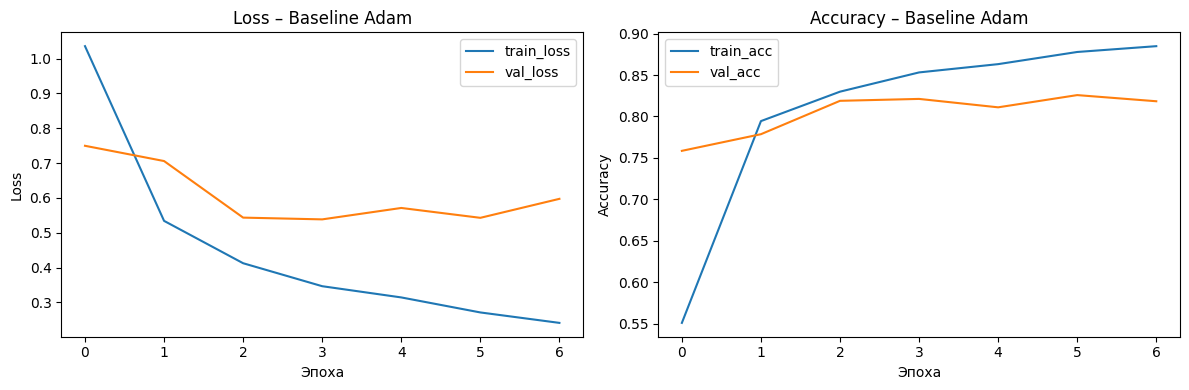


===== Эксперимент 2: Adam - Bigger embedding =====
Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 51s 84ms/step - accuracy: 0.6383 - loss: 0.8875 - val_accuracy: 0.7646 - val_loss: 0.7735
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.8109 - loss: 0.4776 - val_accuracy: 0.7974 - val_loss: 0.6441
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accuracy: 0.8435 - loss: 0.3745 - val_accuracy: 0.8146 - val_loss: 0.5814
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


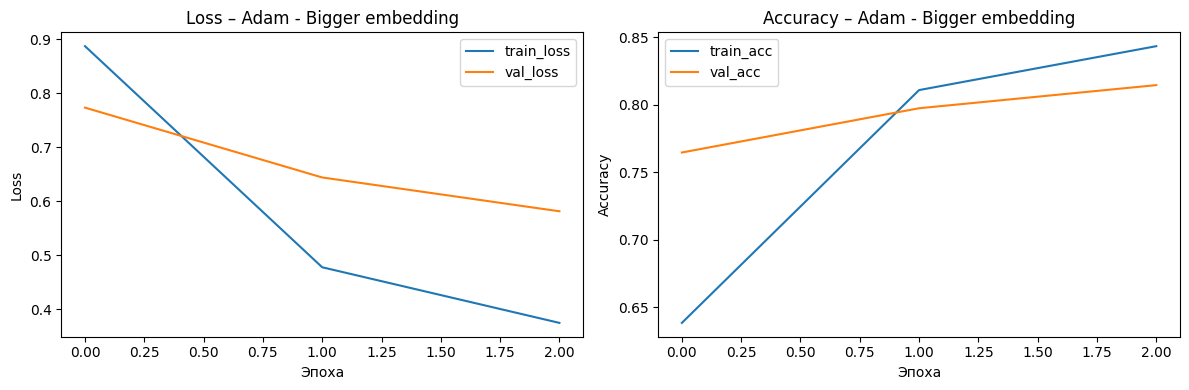


===== Эксперимент 3: Adam - More LSTM units =====
Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 80s 132ms/step - accuracy: 0.5471 - loss: 1.0839 - val_accuracy: 0.7470 - val_loss: 0.7982
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 72s 121ms/step - accuracy: 0.7785 - loss: 0.5757 - val_accuracy: 0.8030 - val_loss: 0.6239
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 79s 131ms/step - accuracy: 0.8211 - loss: 0.4336 - val_accuracy: 0.8065 - val_loss: 0.5856
299/299 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


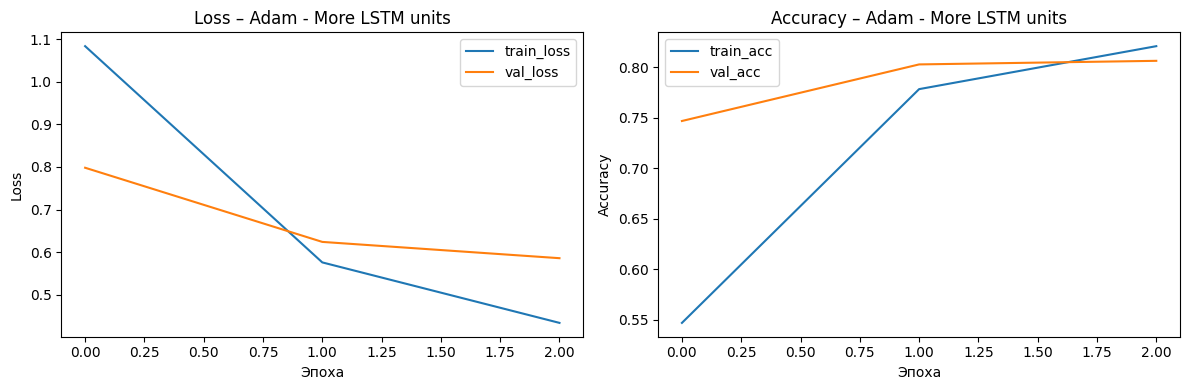


===== Эксперимент 4: Adam - Higher dropout =====
Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.5511 - loss: 1.0673 - val_accuracy: 0.7922 - val_loss: 0.6761
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.7833 - loss: 0.5931 - val_accuracy: 0.8123 - val_loss: 0.6210
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.8167 - loss: 0.4694 - val_accuracy: 0.8121 - val_loss: 0.5772
299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


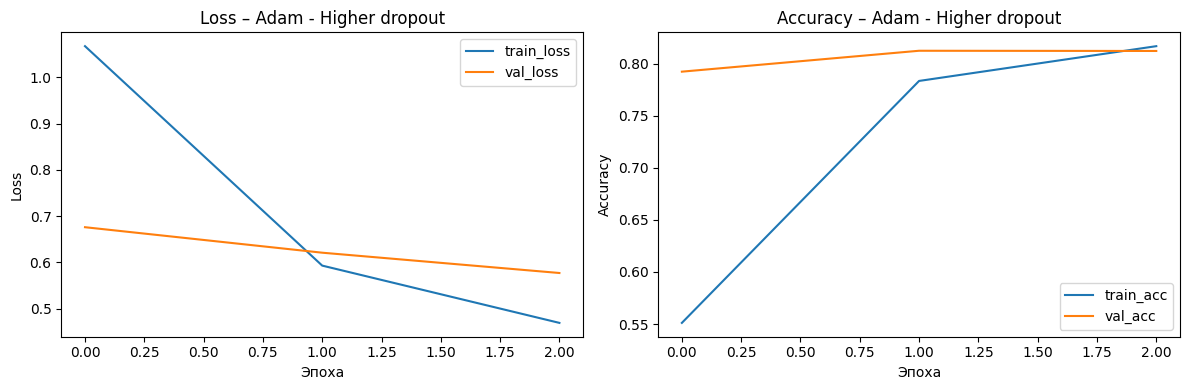


===== Эксперимент 5: Adam - Lower learning rate =====
Epoch 1/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.5353 - loss: 1.0837 - val_accuracy: 0.7376 - val_loss: 0.7679
Epoch 2/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 73ms/step - accuracy: 0.7668 - loss: 0.5860 - val_accuracy: 0.7847 - val_loss: 0.6721
Epoch 3/20
598/598 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.8247 - loss: 0.4553 - val_accuracy: 0.8196 - val_loss: 0.5853
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


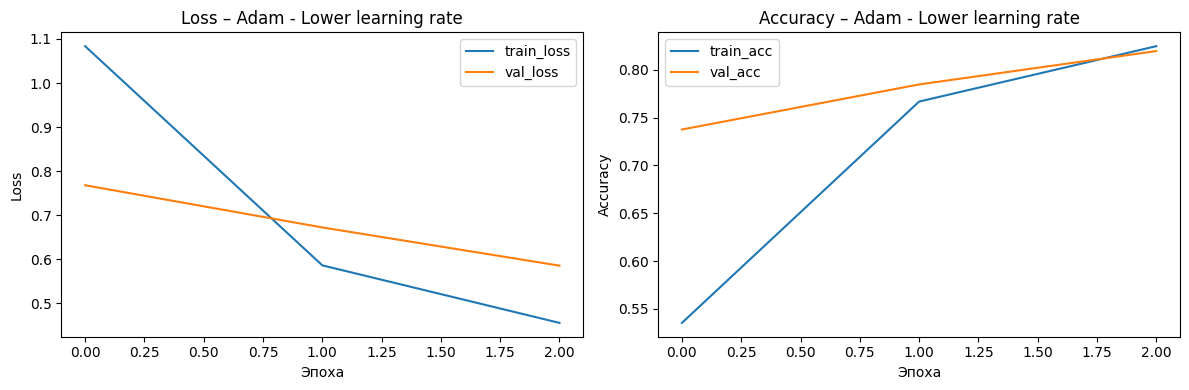


===== ИТОГОВЫЕ РЕЗУЛЬТАТЫ =====


,Experiment,Name,Embedding,LSTM units,Dropout,Optimizer,LR,Best Val Acc,Final Val Acc,F1-Score,Final Val Loss
0,1,Baseline Adam,100,128,0.3,Adam,0.0010,0.825773,0.818353,0.820685,0.597470
1,2,Adam - Bigger embedding,200,128,0.3,Adam,0.0010,0.814590,0.814590,0.769718,0.581407
2,3,Adam - More LSTM units,100,256,0.3,Adam,0.0010,0.806543,0.806543,0.742121,0.585616
3,4,Adam - Higher dropout,100,128,0.5,Adam,0.0010,0.812291,0.812082,0.798971,0.577160
4,5,Adam - Lower learning rate,100,128,0.3,Adam,0.0005,0.819607,0.819607,0.744472,0.585302



>>> ЛУЧШАЯ МОДЕЛЬ: Baseline Adam с точностью 82.58%


In [ ]:
# Список экспериментов
experiments = [
    {
        "name": "Baseline Adam",
        "embed_dim": 100,
        "lstm_units": 128,
        "dropout": 0.3,
        "optimizer": Adam(learning_rate=1e-3),
        "batch_size": 64,
        "epochs": 20
    },
    {
        "name": "Adam - Bigger embedding",
        "embed_dim": 200,
        "lstm_units": 128,
        "dropout": 0.3,
        "optimizer": Adam(learning_rate=1e-3),
        "batch_size": 64,
        "epochs": 20
    },
    {
        "name": "Adam - More LSTM units",
        "embed_dim": 100,
        "lstm_units": 256,
        "dropout": 0.3,
        "optimizer": Adam(learning_rate=1e-3),
        "batch_size": 64,
        "epochs": 20
    },
    {
        "name": "Adam - Higher dropout",
        "embed_dim": 100,
        "lstm_units": 128,
        "dropout": 0.5,
        "optimizer": Adam(learning_rate=1e-3),
        "batch_size": 64,
        "epochs": 20
    },
    {
        "name": "Adam - Lower learning rate",
        "embed_dim": 100,
        "lstm_units": 128,
        "dropout": 0.3,
        "optimizer": Adam(learning_rate=5e-4),
        "batch_size": 64,
        "epochs": 20
    },
]

# Early Stopping callback
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

# Вычисляем веса классов (один раз для всех экспериментов)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weight_dict = dict(enumerate(class_weights))

print("Веса классов:")
for i, weight in class_weight_dict.items():
    print(f"  {le.classes_[i]}: {weight:.2f}")

results = []

def run_experiment(idx, cfg):
    print(f"\n===== Эксперимент {idx}: {cfg['name']} =====")
    
    # Создаём модель
    model = build_lstm_model(
        max_words=max_words,
        maxlen=maxlen,
        embedding_dim=cfg["embed_dim"],
        num_classes=df['Topic_group'].nunique(),
        lstm_units=cfg["lstm_units"],
        dropout=cfg["dropout"]
    )
    
    # Перекомпилируем с нужным оптимизатором
    model.compile(
        optimizer=cfg["optimizer"],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # Обучаем с весами классов
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        callbacks=callbacks,
        class_weight=class_weight_dict,  # ← Штрафуем за редкие классы
        verbose=1
    )
    
    # Вычисляем F1-score
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true_classes, y_pred_classes, average='macro')
    
    return model, history, f1


# Запуск всех экспериментов
for i, cfg in enumerate(experiments, start=1):
    model, history, f1 = run_experiment(i, cfg)  
    
    # Финальные метрики
    final_val_loss = history.history["val_loss"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    best_val_acc = max(history.history["val_accuracy"])
    
    results.append({
        "Experiment": i,
        "Name": cfg["name"],
        "Embedding": cfg["embed_dim"],
        "LSTM units": cfg["lstm_units"],
        "Dropout": cfg["dropout"],
        "Optimizer": cfg["optimizer"].__class__.__name__,
        "LR": cfg["optimizer"].learning_rate.numpy(),
        "Best Val Acc": best_val_acc,
        "Final Val Acc": final_val_acc,
        "F1-Score": f1,  # Добавили F1
        "Final Val Loss": final_val_loss
    })

    
    # График Loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"Loss – {cfg['name']}")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    
    # График Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"Accuracy – {cfg['name']}")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Сохраняем модель
    model.save(f"ticket_model_exp_{i}.keras")

# Таблица результатов
results_df = pd.DataFrame(results)
print("\n===== ИТОГОВЫЕ РЕЗУЛЬТАТЫ =====")
display(results_df)

# Лучшая модель
best_idx = results_df["Best Val Acc"].idxmax()
print(f"\n>>> ЛУЧШАЯ МОДЕЛЬ: {results_df.loc[best_idx, 'Name']} с точностью {results_df.loc[best_idx, 'Best Val Acc']:.2%}")

## Оценка лучшей модели

In [74]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

# Загружаем лучшую модель 
best_model = load_model("ticket_model_exp_1.keras")

# Предсказания на тестовых данных
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification Report
print("=== Отчёт по классификации ===\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))


299/299 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
=== Отчёт по классификации ===

                       precision    recall  f1-score   support

               Access       0.88      0.88      0.88      1455
Administrative rights       0.65      0.81      0.72       342
           HR Support       0.86      0.79      0.83      2107
             Hardware       0.84      0.76      0.80      2760
     Internal Project       0.74      0.90      0.81       451
        Miscellaneous       0.76      0.82      0.79      1400
             Purchase       0.83      0.93      0.88       497
              Storage       0.81      0.91      0.86       556

             accuracy                           0.82      9568
            macro avg       0.80      0.85      0.82      9568
         weighted avg       0.83      0.82      0.82      9568



## Примеры для теста

In [81]:
# Функция для предсказания класса нового тикета
def predict_ticket(text):
    # Очистка текста
    clean = preprocess_text(text)
    # Токенизация
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=maxlen)
    # Предсказание
    pred = best_model.predict(padded, verbose=0)
    class_idx = np.argmax(pred)
    confidence = pred[0][class_idx]
    class_name = le.inverse_transform([class_idx])[0]
    return class_name, confidence

# Примеры предсказаний
test_examples = [
    # Hardware
    "My laptop //!@ screen is ?@? broken and I need a replacement",
    
    # Access
    "I forgot my password and cannot login to the system",
    
    # Purchase
    "I need a monitor replacement",
    
    # Storage
    "My disk space is full, please increase storage quota",
    
    # HR Support
    "I need help with my vacation request and leave balance",
    
    # Internal Project
    "Please add me to the new CRM migration project team",
    
    # Administrative rights
    "I need admin rights to install software on my computer",
    
    # Miscellaneous
    "The office coffee machine is not working properly"
]

print("=== Примеры предсказаний ===\n")
for text in test_examples:
    predicted_class, conf = predict_ticket(text)
    print(f"Текст: {text}")
    print(f"Предсказание: {predicted_class} (уверенность: {conf:.2%})\n")


=== Примеры предсказаний ===

Текст: My laptop //!@ screen is ?@? broken and I need a replacement
Предсказание: Hardware (уверенность: 98.82%)

Текст: I forgot my password and cannot login to the system
Предсказание: Access (уверенность: 94.67%)

Текст: I need a monitor replacement
Предсказание: Hardware (уверенность: 90.51%)

Текст: My disk space is full, please increase storage quota
Предсказание: Storage (уверенность: 99.90%)

Текст: I need help with my vacation request and leave balance
Предсказание: HR Support (уверенность: 91.83%)

Текст: Please add me to the new CRM migration project team
Предсказание: Miscellaneous (уверенность: 84.11%)

Текст: I need admin rights to install software on my computer
Предсказание: Administrative rights (уверенность: 86.62%)

Текст: The office coffee machine is not working properly
Предсказание: Hardware (уверенность: 55.64%)

